In [ ]:
èppipip install pandas numpy scikit-learn xgboost matplotlib seabornseabornseabornseaborn

##IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

##LOAD DATA

In [ ]:
df = pd.read_csv("Etho-Agri Dataset_Enhanced.csv")
print(df.head())

   Region crop type  Year   Area cultivated(Ha)  Production(kg)  \
0  Tigray      Teff  1996               87880.0        60827000   
1  Tigray    Barely  1996               87350.0        81711000   
2  Tigray     Wheat  1996               84550.0        84653000   
3  Tigray     Maize  1996               45050.0        67963000   
4  Tigray   Sorghum  1996               96140.0       172968000   

   Yeild (kg/ha)  Year_Since_Start  Decade  Is_Recent  Region_Code  ...  \
0            692                 0    1990          0            9  ...   
1            935                 0    1990          0            9  ...   
2           1001                 0    1990          0            9  ...   
3           1509                 0    1990          0            9  ...   
4           1799                 0    1990          0            9  ...   

   Region_Growth_Rate  Crop_Code  Crop_Avg_Yield  Crop_Trend  \
0                 NaN          5      598.719231         NaN   
1            0.343

## DATA CLEANING

In [ ]:


# Fix typo in 'crop type' column
df["crop type"] = df["crop type"].replace({"Barely": "Barley"})

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values with median (more robust to outliers than mean)
df.fillna(df.median(numeric_only=True), inplace=True)

# ==============================
# ENCODING CATEGORICAL FEATURES
# ==============================

le_region = LabelEncoder()
le_crop = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"].astype(str))
df["crop type"] = le_crop.fit_transform(df["crop type"].astype(str))

# ==============================
# FEATURE SELECTION
# ==============================

# Target (Corrected name from CSV)
target_col = "Yeild (kg/ha)"
y = df[target_col]

# Features: Dropping non-numeric object columns and the target
X = df.select_dtypes(include=[np.number]).drop(columns=[target_col])

# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


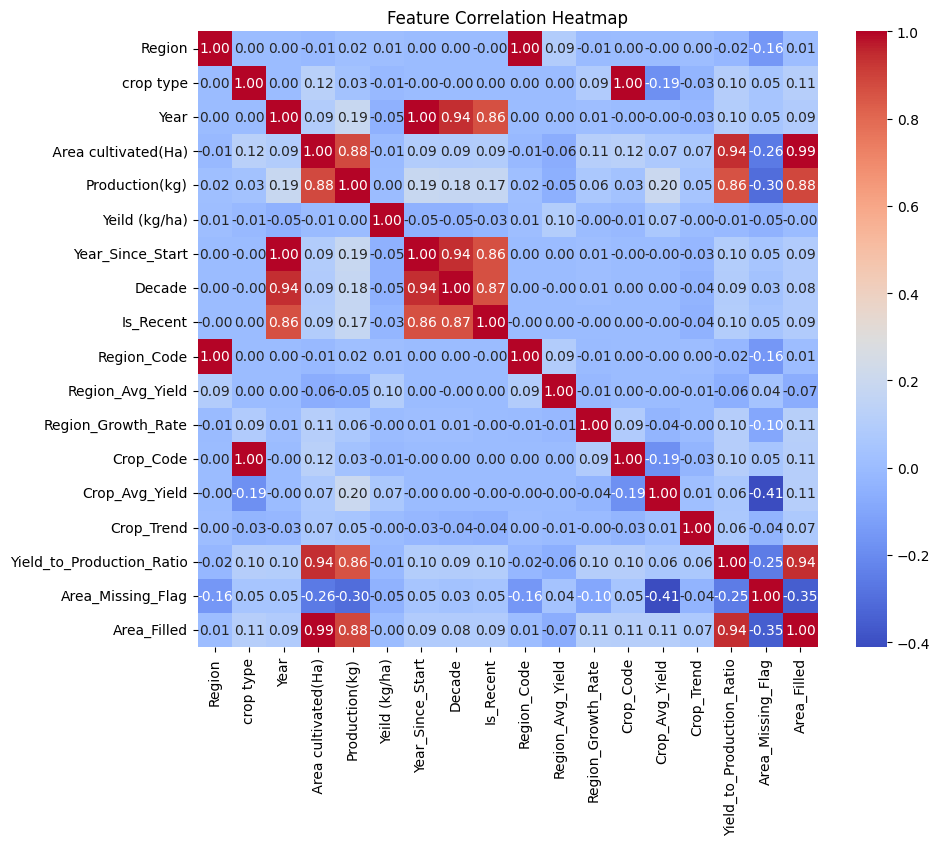

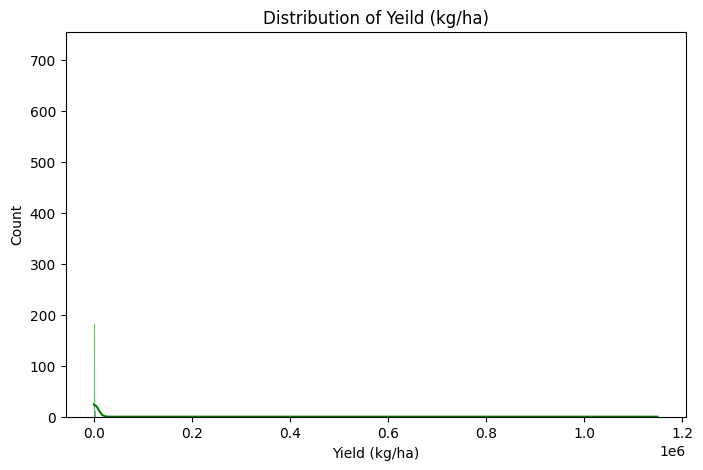

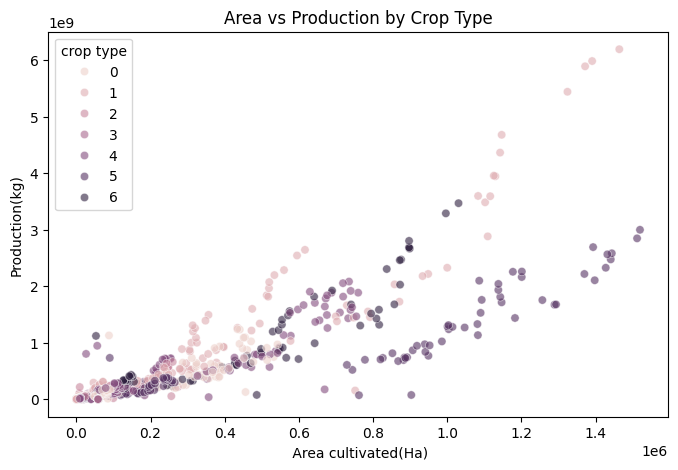

In [ ]:
# ==============================
# PRE-TRAINING VISUALIZATIONS
# ==============================

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df[target_col], kde=True, color='green')
plt.title(f"Distribution of {target_col}")
plt.xlabel("Yield (kg/ha)")
plt.show()

# 3. Relationship between Area and Production (Key Drivers)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=' Area cultivated(Ha)', y='Production(kg)', hue='crop type', alpha=0.6)
plt.title("Area vs Production by Crop Type")
plt.show()

## MODELS Training And evaluation

In [ ]:

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, r2])

    print(f"{name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 30)

Linear Regression
RMSE: 55092.55566885924
R2 Score: 0.018061870139672198
------------------------------
Random Forest
RMSE: 23264.053804647545
R2 Score: 0.8249068832689989
------------------------------
Gradient Boosting
RMSE: 20645.91854656421
R2 Score: 0.8620992254770772
------------------------------
XGBoost
RMSE: 4156.916405221544
R2 Score: 0.9944096207618713
------------------------------


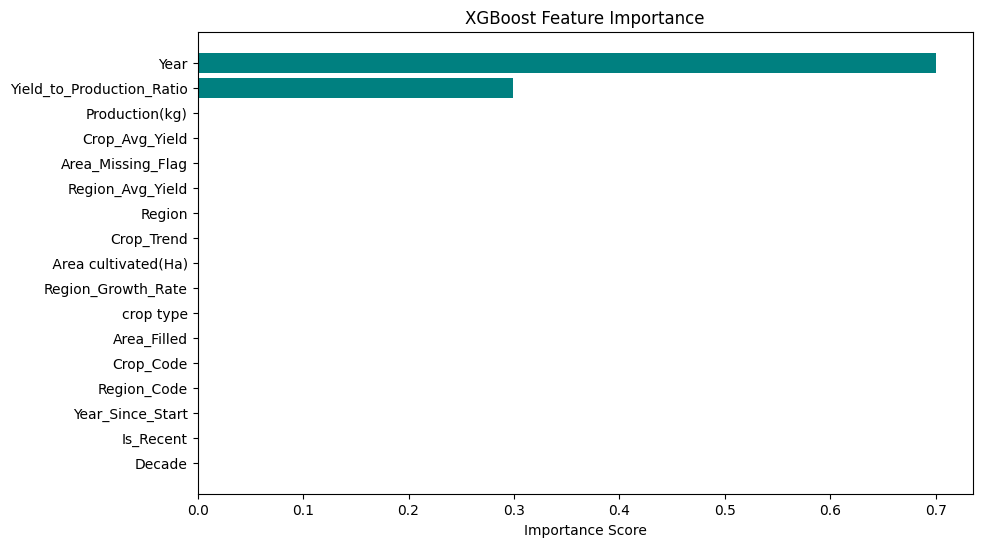

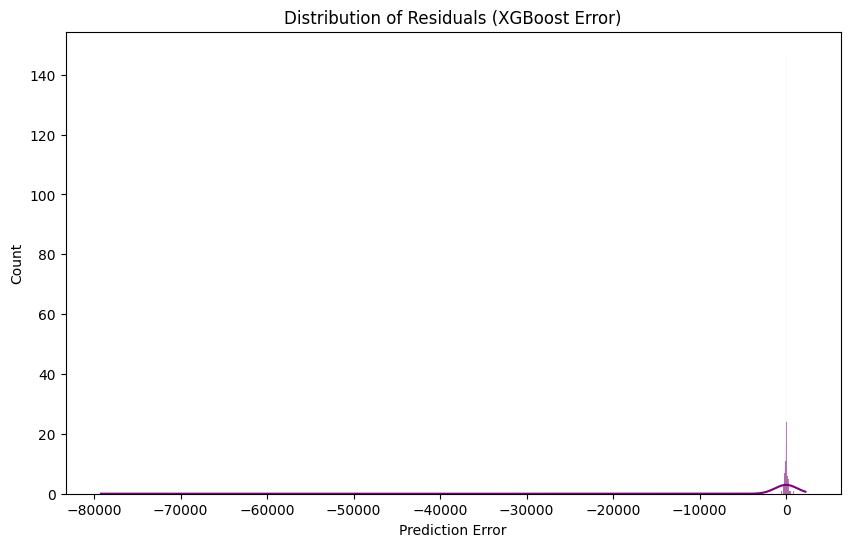

In [ ]:
# ==============================
# POST-TRAINING VISUALIZATIONS
# ==============================

# 1. Feature Importance for XGBoost
plt.figure(figsize=(10, 6))
best_model = models['XGBoost']
importance = best_model.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importance)

plt.barh(range(len(sorted_idx)), importance[sorted_idx], align='center', color='teal')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# 2. Predicted vs Actual Residual Analysis
plt.figure(figsize=(10, 6))
y_pred_xgb = best_model.predict(X_test)
residuals = y_test - y_pred_xgb
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribution of Residuals (XGBoost Error)")
plt.xlabel("Prediction Error")
plt.show()

## Model Comparison

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

print("\nModel Comparison:")
print(results_df)


Model Comparison:
               Model          RMSE        R2
0  Linear Regression  55092.555669  0.018062
1      Random Forest  23264.053805  0.824907
2  Gradient Boosting  20645.918547  0.862099
3            XGBoost   4156.916405  0.994410


## Visualization

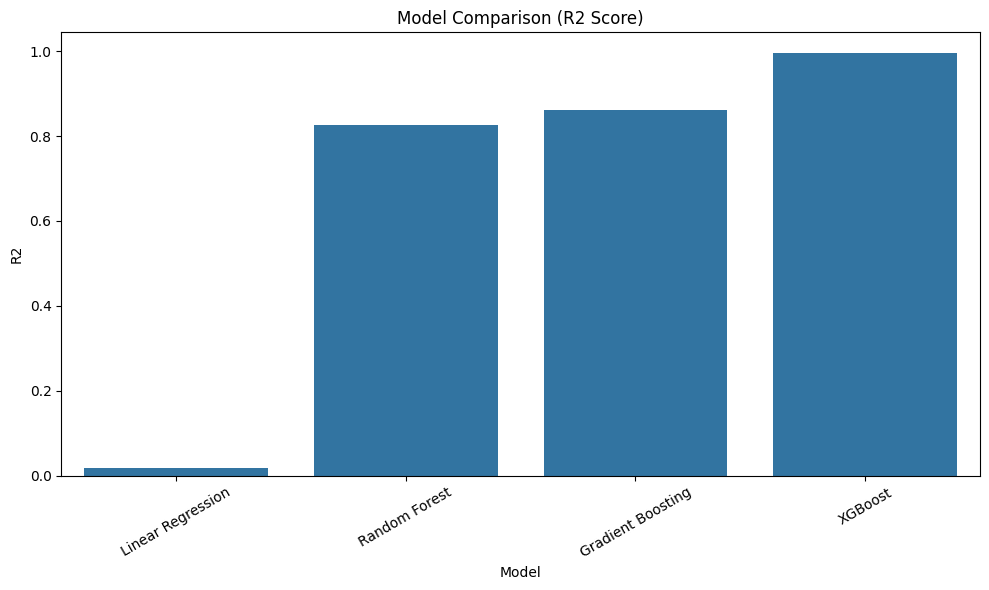

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

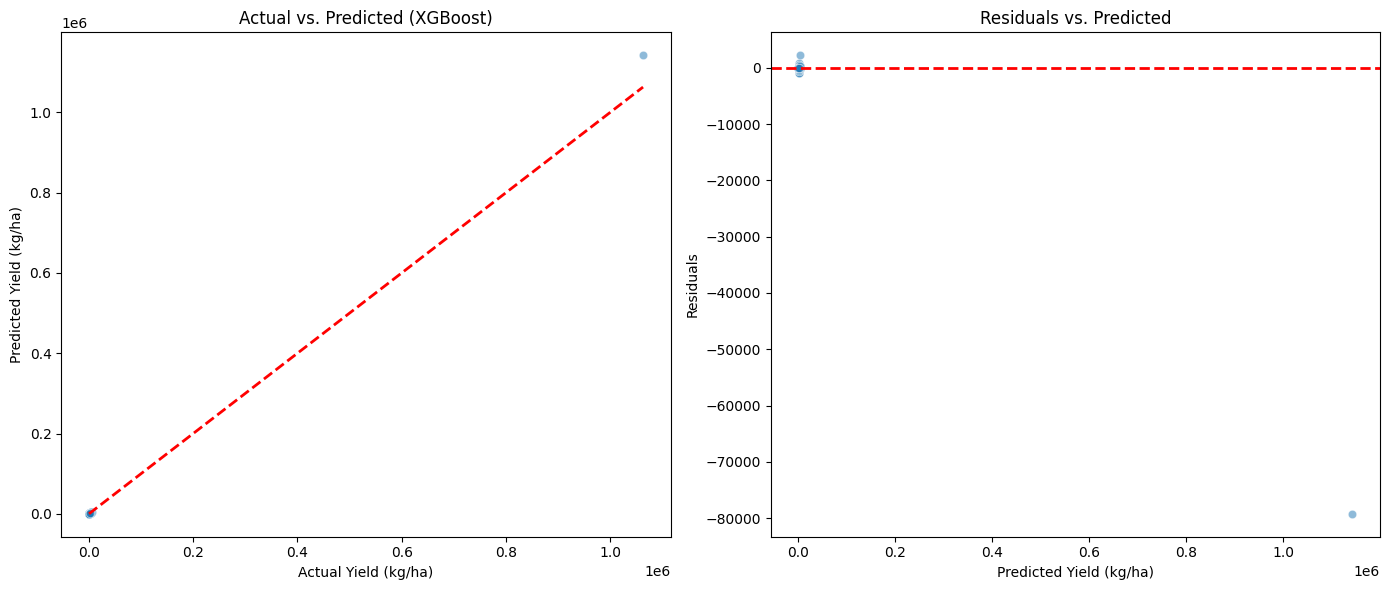

In [ ]:
# Get predictions from the best model (XGBoost)
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test)

fig, axs = plt.subplots(ncols=2, figsize=(14, 6))

# 1. Actual vs Predicted Plot
sns.scatterplot(x=y_test, y=y_pred_best, ax=axs[0], alpha=0.5)
axs[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axs[0].set_xlabel('Actual Yield (kg/ha)')
axs[0].set_ylabel('Predicted Yield (kg/ha)')
axs[0].set_title('Actual vs. Predicted (XGBoost)')

# 2. Residuals Plot
residuals = y_test - y_pred_best
sns.scatterplot(x=y_pred_best, y=residuals, ax=axs[1], alpha=0.5)
axs[1].axhline(y=0, color='r', linestyle='--', lw=2)
axs[1].set_xlabel('Predicted Yield (kg/ha)')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.show()